In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import os
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [161]:
df= pd.read_csv(r"E:/AI_Projects/NLP_Projects/Language_detection/Data/Language Detection.csv")

In [162]:
df.columns

Index(['Text', 'Language'], dtype='str')

In [163]:
df.shape

(10337, 2)

In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10337 entries, 0 to 10336
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Text      10337 non-null  str  
 1   Language  10337 non-null  str  
dtypes: str(2)
memory usage: 1.9 MB


In [165]:
import re
def clean_text(text):
    # Remove special characters and digits
    #text = re.sub(r'[^a-zA-Z\s]', '', text)
    #text = re.sub(r'\s+', ' ', text).strip()
    # Convert to lowercase
    text = text.lower()
    text=text.strip()
    return text

In [166]:
df['Clean_Text']=df['Text'].apply(clean_text)

In [167]:
df[['Clean_Text','Language']].tail(2)

,Clean_Text,Language
10335,ಅವಳು ಈಗ ಹೆಚ್ಚು ಚಿನ್ನದ ಬ್ರೆಡ್ ಬಯಸುವುದಿಲ್ಲ ಎಂದು ...,Kannada
10336,ಟೆರ್ರಿ ನೀವು ನಿಜವಾಗಿಯೂ ಆ ದೇವದೂತನಂತೆ ಸ್ವಲ್ಪ ಕಾಣು...,Kannada


In [168]:
df['Language'].value_counts()

Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64

In [171]:
kannada_df=df[df['Language'].astype(str).str.lower()=='kannada']
print(f"Number of Kannada samples: {len(kannada_df)}")
print(kannada_df[['Clean_Text','Language']].tail(10).to_string(index=False))

Number of Kannada samples: 369
                                                                                                                                                                                                                             Clean_Text Language
                                                                                                                                      ಗಾಡಿಯಲ್ಲಿ ಮನೆಯಲ್ಲಿ ನಾರ್ಸಿಸ್ ಅವಳು ಮನೆಗೆ ತಲುಪಿದಾಗ ಮಾಡಿದ ಆಯ್ಕೆಗಳ ಬಗ್ಗೆ ಆಳವಾಗಿ ಯೋಚಿಸಲು ಪ್ರಾರಂಭಿಸಿದಳು.  Kannada
                                                                                         ಅವಳು ಮನೆಯಲ್ಲಿ ಕುಳಿತಿದ್ದ ತನ್ನ ತಾಯಿಯನ್ನು ತಬ್ಬಿಕೊಳ್ಳಲು ಓಡಿಹೋದಳು ಅಥವಾ ಸಹೋದರಿ ಓ ನನ್ನ ಸಿಹಿ ಮಗಳು ನಾನು ಮತ್ತೆ ನಿನ್ನನ್ನು ನೋಡುವುದಿಲ್ಲ ಎಂದು ನಾನು ಭಾವಿಸಿದೆ.  Kannada
                                                       ಓಹ್ ತಾಯಿ ನಾನು ನಿನ್ನನ್ನು ತುಂಬಾ ಪ್ರೀತಿಸುತ್ತೇನೆ ಮತ್ತು ನೀವು ಸರಿಯಾದ ನೋಟ ಮತ್ತು ಸಂಪತ್ತು ಎಲ್ಲವೂ ಚಿನ್ನದ ಬ್ರೆಡ್ ನಿಷ್ಪ್ರಯೋಜಕವಾಗಿದ್ದರಿಂದ ನಾನು ಅದನ್ನು ತಿನ್ನಲು ಸಾಧ್ಯವಾಗಲಿಲ್ಲ ಮತ್ತು ಮನುಷ್ಯ ಕೂಡ.  Kannada
     

In [172]:
text = "ನಿಮ್ಮ ತಪ್ಪು ಏನು ಬಂದಿದೆಯೆಂದರೆ ಆ ದಿನದಿಂದ ನಿಮಗೆ"

print("Original:")
print(text)

print("\nCleaned:")
print(clean_text(text))

Original:
ನಿಮ್ಮ ತಪ್ಪು ಏನು ಬಂದಿದೆಯೆಂದರೆ ಆ ದಿನದಿಂದ ನಿಮಗೆ

Cleaned:
ನಿಮ್ಮ ತಪ್ಪು ಏನು ಬಂದಿದೆಯೆಂದರೆ ಆ ದಿನದಿಂದ ನಿಮಗೆ


In [ ]:
text = "ನಿಮ್ಮ ತಪ್ಪು ಏನು ಬಂದಿದೆಯೆಂದರೆ ಆ ದಿನದಿಂದ ನಿಮಗೆ"
cleaned_text=clean_text(text)

#vecotor=tfVectorizer.transform([cleaned_text])
vecotor=CVectorizer.transform([cleaned_text])

print("Vectorized:",vecotor.shape)
print("non-zero elements:", vecotor.nnz)

Vectorized: (1, 5000)
non-zero elements: 0


<Axes: xlabel='Language'>

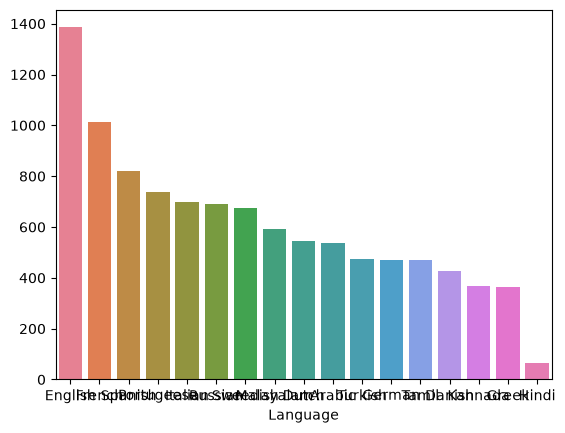

In [169]:
sns.barplot(x=df['Language'].value_counts().index, y=df['Language'].value_counts().values,hue=df['Language'].value_counts().index)

In [136]:
CVectorizer= CountVectorizer(analyzer='char', ngram_range=(2,5),lowercase =True, max_features=5000,
min_df=1)
X=CVectorizer.fit_transform(df['Clean_Text'])

CVectorizer.get_feature_names_out()


array([' a', ' a ', ' a c', ..., 'zvous', 'zz', 'zza'],
      shape=(5000,), dtype=object)

In [154]:
tfVectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2,5),min_df=1, max_features=5000,
    sublinear_tf=True, norm='l2')
tfX = tfVectorizer.fit_transform(df['Clean_Text'])

tfVectorizer.get_feature_names_out()

array([' a', ' a ', ' a c', ..., 'zvous', 'zz', 'zza'],
      shape=(5000,), dtype=object)

In [138]:
Y=df['Language']

In [140]:
#X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(tfX, Y, test_size=0.15, random_state=42, stratify=Y)


lor_model = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs',random_state=42)
lor_model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [141]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred=lor_model.predict(X_test)
print("Accuracy of the model is: ", lor_model.score(X_test, y_test)*100)
print("Predicted values are: ", y_pred)
print("****  Classification Report of the model **** \n")
print(classification_report(y_test,y_pred))

print("Accuracy Score: ", accuracy_score(y_test,y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))


Accuracy of the model is:  74.27466150870407
Predicted values are:  ['German' 'Russian' 'Spanish' ... 'French' 'French' 'Spanish']
****  Classification Report of the model **** 

              precision    recall  f1-score   support

      Arabic       0.00      0.00      0.00        80
      Danish       1.00      0.95      0.98        64
       Dutch       0.99      0.96      0.98        82
     English       0.97      0.98      0.97       208
      French       0.99      0.97      0.98       152
      German       0.97      1.00      0.99        71
       Greek       0.50      0.04      0.07        55
       Hindi       0.00      0.00      0.00        10
     Italian       0.98      0.96      0.97       105
     Kannada       0.00      0.00      0.00        55
   Malayalam       0.00      0.00      0.00        89
  Portugeese       0.96      0.95      0.95       111
     Russian       0.21      0.94      0.34       104
     Spanish       0.98      0.98      0.98       123
    Sweedi

In [145]:
nb_model =   MultinomialNB(alpha=1.0, fit_prior=True)
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [146]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred=nb_model.predict(X_test)
print("Accuracy of the model is: ", nb_model.score(X_test, y_test)*100)
print("Predicted values are: ", y_pred)
print("****  Classification Report of the model **** \n")
print(classification_report(y_test,y_pred))

print("Accuracy Score: ", accuracy_score(y_test,y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))



Accuracy of the model is:  68.60090264345583
Predicted values are:  ['German' 'English' 'Spanish' ... 'French' 'French' 'Spanish']
****  Classification Report of the model **** 

              precision    recall  f1-score   support

      Arabic       0.00      0.00      0.00        80
      Danish       0.98      0.88      0.93        64
       Dutch       0.99      0.99      0.99        82
     English       0.31      1.00      0.48       208
      French       0.95      0.99      0.97       152
      German       0.99      0.97      0.98        71
       Greek       0.67      0.04      0.07        55
       Hindi       0.00      0.00      0.00        10
     Italian       0.99      0.96      0.98       105
     Kannada       0.00      0.00      0.00        55
   Malayalam       0.00      0.00      0.00        89
  Portugeese       0.95      0.95      0.95       111
     Russian       0.50      0.02      0.04       104
     Spanish       0.98      0.98      0.98       123
    Sweedi

In [147]:
vsc_model = LinearSVC(random_state=42, C=1.0, max_iter=2000)
vsc_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [148]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred=vsc_model.predict(X_test)
print("Accuracy of the model is: ", vsc_model.score(X_test, y_test)*100)
print("Predicted values are: ", y_pred)
print("****  Classification Report of the model **** \n")
print(classification_report(y_test,y_pred))

print("Accuracy Score: ", accuracy_score(y_test,y_pred))


Accuracy of the model is:  74.85493230174082
Predicted values are:  ['German' 'Russian' 'Spanish' ... 'French' 'French' 'Spanish']
****  Classification Report of the model **** 

              precision    recall  f1-score   support

      Arabic       0.00      0.00      0.00        80
      Danish       0.97      0.97      0.97        64
       Dutch       0.96      0.98      0.97        82
     English       0.97      0.98      0.98       208
      French       0.96      0.98      0.97       152
      German       0.99      1.00      0.99        71
       Greek       0.40      0.04      0.07        55
       Hindi       0.00      0.00      0.00        10
     Italian       0.96      0.98      0.97       105
     Kannada       0.00      0.00      0.00        55
   Malayalam       0.33      0.01      0.02        89
  Portugeese       0.95      0.95      0.95       111
     Russian       0.22      0.92      0.35       104
     Spanish       0.97      0.98      0.97       123
    Sweedi

In [153]:
text = "ನಿಮ್ಮ ತಪ್ಪು ಏನು ಬಂದಿದೆಯೆಂದರೆ ಆ ದಿನದಿಂದ ನಿಮಗೆ"

text_vectorized = CVectorizer.transform([text]).toarray()
predicted_language = lor_model.predict(text_vectorized)
print(f"The predicted language for the text '{text}' is: {predicted_language[0]}")

The predicted language for the text 'ನಿಮ್ಮ ತಪ್ಪು ಏನು ಬಂದಿದೆಯೆಂದರೆ ಆ ದಿನದಿಂದ ನಿಮಗೆ' is: Russian


In [155]:
print(vsc_model.classes_)
print("Features:", len(tfVectorizer.get_feature_names_out()))

X_test = tfVectorizer.transform([
    "ನಿಮ್ಮ ತಪ್ಪು ಏನು ಬಂದಿದೆಯೆಂದರೆ ಆ ದಿನದಿಂದ ನಿಮಗೆ"
])

print("Non-zero features:", X_test.nnz)

['Arabic' 'Danish' 'Dutch' 'English' 'French' 'German' 'Greek' 'Hindi'
 'Italian' 'Kannada' 'Malayalam' 'Portugeese' 'Russian' 'Spanish'
 'Sweedish' 'Tamil' 'Turkish']
Features: 5000
Non-zero features: 0
